In [ ]:
# Step 1: Install necessary library for handling Excel files.
# !pip is used to install library

!pip install pandas matplotlib

# Step 2: Import necessary libraries
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt

# Step 3: Upload the Financial Data File (Excel or CSV)
print("Please upload DHS4_Data_Bender_Carliez_Guichard_Rabache.csv")
uploaded = files.upload()  # Allows users to upload a file from their local system

# Get the uploaded file name
file_name = list(uploaded.keys())[0]   # 0: picks the first filename
print(f"\nUploaded file: {file_name}")

# In your Topic 1 -> Dataset: you have "data.csv", "data.xlsx", "sample_prices.csv"
# Import any one file or import multiple files in different run.

# Determine the file type and read the file
if file_name.endswith('.csv'):
    df = pd.read_csv(file_name)  # Read CSV file
elif file_name.endswith('.xlsx'):
    df = pd.read_excel(file_name)  # Read Excel file
else:
    raise ValueError(
        "Unsupported file format. "
        "Please upload a CSV or Excel file."
    )


Please upload DHS4_Data_Bender_Carliez_Guichard_Rabache.csv


Saving DHS4_Data_Bender_Carliez_Guichard_Rabache.csv to DHS4_Data_Bender_Carliez_Guichard_Rabache (1).csv

Uploaded file: DHS4_Data_Bender_Carliez_Guichard_Rabache (1).csv


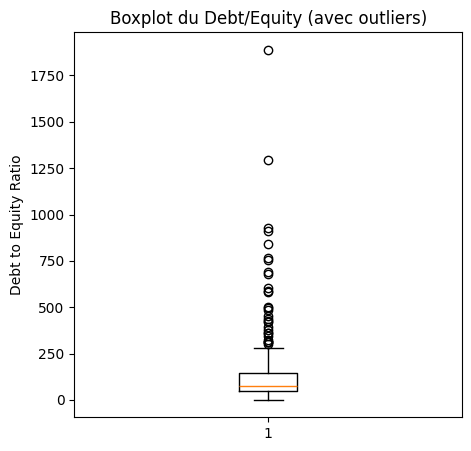

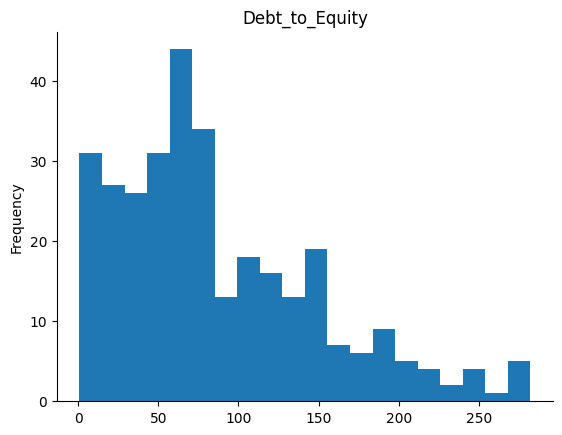

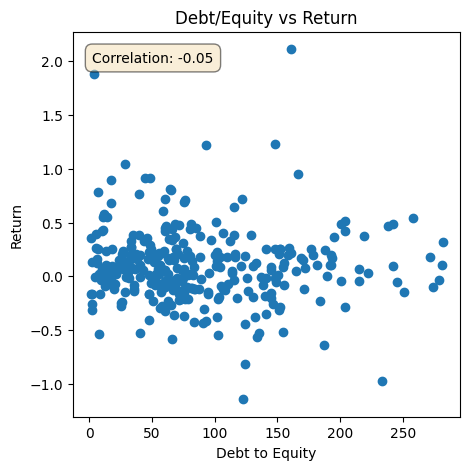

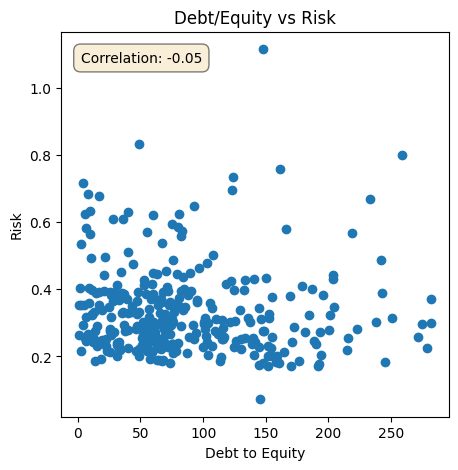

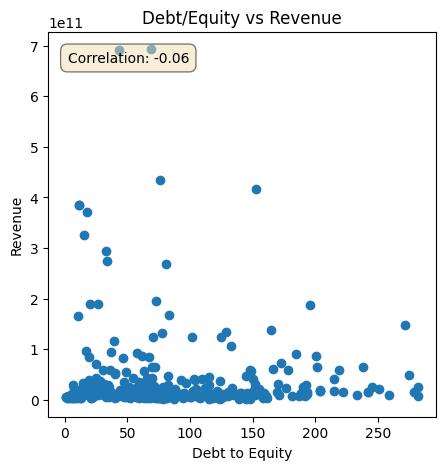

       Debt_to_Equity        Risk      Return       Revenue
count      344.000000  344.000000  344.000000  3.440000e+02
mean       129.164189    0.336358    0.095321  3.928071e+10
std        181.623974    0.134917    0.359176  8.062123e+10
min          0.887000    0.072489   -1.143474  9.405610e+08
25%         45.656000    0.244614   -0.108462  7.490325e+09
50%         75.621000    0.302432    0.063679  1.436450e+10
75%        146.734500    0.388337    0.239145  3.237450e+10
max       1888.690000    1.114902    2.111721  6.931530e+11
✅ CSV exporté: DHS4_output_cleaned.csv


,Ticker,Debt_to_Equity,Risk,Return,Revenue
0,A,56.421,0.316108,0.093843,6.788000e+09
2,AAP,258.405,0.800430,0.540952,8.624327e+09
3,AAPL,152.411,0.326409,0.251890,4.161610e+11
6,ABNB,29.324,0.390401,-0.002167,1.158000e+10
7,ABT,25.310,0.213564,0.093911,4.384300e+10
...,...,...,...,...,...
394,XEL,159.282,0.200991,0.266672,1.422800e+10
395,XOM,15.672,0.231639,0.020747,3.262450e+11
396,XYL,18.253,0.246674,0.254774,8.894000e+09
398,ZBH,61.603,0.264256,-0.038013,7.833800e+09


In [ ]:

# 1. CONVERSION IN DATAFRAME + cleaning
# (Session 2: df.dropna, subsetting)

# df = pd.DataFrame(data_list, columns=["Ticker", "Debt_to_Equity", "Return", "Risk", "Revenue"])
df = df.dropna()   # remove lines with missing values


# 2. REMOVE OUTLIERS WITH IQR
# (Session 3: aggregation + vectorisation with pandas)

Q1 = df["Debt_to_Equity"].quantile(0.25)
Q3 = df["Debt_to_Equity"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df["Debt_to_Equity"] >= lower) & (df["Debt_to_Equity"] <= upper)]


# 3. VISUALISATION (Session 4: Tell the story with data)


# BOX PLOT (with outliers)
plt.figure(figsize=(5,5))
plt.boxplot(df["Debt_to_Equity"])
plt.title("Boxplot du Debt/Equity (with outliers)")
plt.ylabel("Debt to Equity Ratio")
plt.show()

#Histogram

df_clean['Debt_to_Equity'].plot(kind='hist', bins=20, title='Debt_to_Equity')
plt.gca().spines[['top', 'right',]].set_visible(False)

#  SCATTER PLOTS (correlation with D/E)
for col in ["Return", "Risk", "Revenue"]:
    correlation = df_clean["Debt_to_Equity"].corr(df_clean[col])
    plt.figure(figsize=(5,5))
    plt.scatter(df_clean["Debt_to_Equity"], df_clean[col])
    plt.title(f"Debt/Equity vs {col}")
    plt.xlabel("Debt to Equity")
    plt.ylabel(col)
    plt.text(
        0.05,
        0.95,
        f'Correlation: {correlation:.2f}',
        horizontalalignment='left',
        verticalalignment='top',
        transform=plt.gca().transAxes,
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5)
    )
    plt.show()
#AI to write the value of the correlation directly on the scatter plot (the last 9 lines )


# 4. Descriptive statisticts
summary_stat=df.describe()
print(summary_stat)


# 5. EXPORT CSV (Session 1: to_csv)

df_clean.to_csv("DHS4_output_cleaned.csv", index=False)
print("✅ CSV exporté: DHS4_output_cleaned.csv")

# 6. Final Preview
df_clean

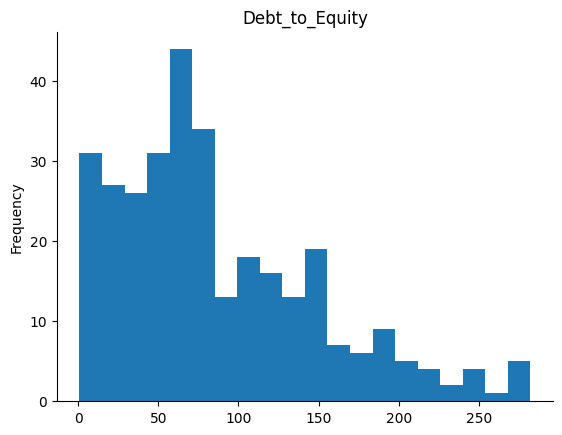

In [ ]:
from matplotlib import pyplot as plt
df_clean['Debt_to_Equity'].plot(kind='hist', bins=20, title='Debt_to_Equity')
plt.gca().spines[['top', 'right',]].set_visible(False)